<a href="https://colab.research.google.com/github/shonnvs-code/Team4-A1-BA820-Project/blob/main/M2_FILES/Shon_Shaju_ProjectM2_Q2_BA820_Team_4_Childcare_Costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Childcare Costs Dataset**
<BR>
Name:Shon Shaju
<br>
Session & team: A1 & Team 4
<br>


# **1. Executive Summary**

Childcare isn't just a family issue; it’s a major economic factor. In the U.S., childcare is often one of the biggest expenses for a household, sometimes costing between 8.9% and 16% of a family's income, in many places, that is more than rent!

Research shows that when prices go up, parents (especially mothers) are often forced to leave the workforce. This project looks beyond just "average prices" to understand the diverse childcare markets across the U.S. We want to understand how costs relate to income, employment, and local economies so policymakers and employers can make better decisions.

# **2.Question under analysis**

Q2.How do U.S. counties cluster into distinct childcare market types based on pricing structure and affordability pressure, and how do these market types differ in maternal labor force participation? Specifically, do clusters exist where maternal labor participation remains high despite extreme childcare cost-to-income ratios, or where participation remains low even at moderate cost levels?

# **3.Loading Data**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
childcare = pd.read_csv('/content/drive/MyDrive/childcare_costs.csv')
counties  = pd.read_csv('/content/drive/MyDrive/counties.csv')

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)
childcare.head()


childcare shape: (34567, 61)
counties shape: (3144, 4)


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [6]:
# mereging both the data sets
df = childcare.merge(counties, on="county_fips_code", how="left")
df

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.4,4.8,0.6,75.9,74.8,...,112.94,147.36,120.38,123.99,110.71,110.71,111.47,Weston County,Wyoming,WY
34563,56045,2015,5.16,7.86,3.16,4.2,7.6,1.6,73.2,82.0,...,110.89,140.36,118.77,118.77,110.89,110.89,110.89,Weston County,Wyoming,WY
34564,56045,2016,3.61,4.67,2.79,3.4,4.5,2.6,69.7,68.1,...,108.85,133.37,117.16,113.55,114.10,111.07,110.31,Weston County,Wyoming,WY
34565,56045,2017,2.24,2.64,1.95,2.3,2.8,2.0,71.4,63.6,...,106.81,126.38,115.55,108.32,117.30,111.26,109.74,Weston County,Wyoming,WY


# **4.EDA**

## 4.1 Prelimanary EDA

Exploratory analysis is conducted on the full set of counties for 2018.

In [15]:
income_col = "mhi_2018"
maternal_lfp_col = "flfpr_20to64_under6"

center_cols = ["mc_infant", "mc_toddler", "mc_preschool"]
family_cols = ["mfcc_infant", "mfcc_toddler", "mfcc_preschool"]
needed_cols = [income_col, maternal_lfp_col] + center_cols + family_cols
for c in needed_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    else:
        raise KeyError(f"Missing column in df: {c}")
#  Average childcare prices (weekly)
df["center_avg"] = df[center_cols].mean(axis=1)
df["family_avg"] = df[family_cols].mean(axis=1)
df["overall_price_avg_weekly"] = df[["center_avg", "family_avg"]].mean(axis=1)

In [16]:
# 3) Structural pricing features
df["infant_preschool_ratio_center"] = df["mc_infant"] / df["mc_preschool"]
df["infant_preschool_ratio_family"] = df["mfcc_infant"] / df["mfcc_preschool"]

df["center_minus_family"] = df["center_avg"] - df["family_avg"]
df["center_over_family"] = df["center_avg"] / df["family_avg"]


In [21]:
# Affordability ratios (unit-consistent + interpretable)
# Original (weekly price / annual income) — tiny numbers
df["afford_ratio_weekly_over_annual_income"] = df["overall_price_avg_weekly"] / df[income_col]

# Better: weekly childcare / weekly income
df["weekly_income"] = df[income_col] / 52
df["afford_ratio_weekly"] = df["overall_price_avg_weekly"] / df["weekly_income"]

# Best for reporting: annualized childcare / annual income
df["annual_childcare_cost"] = df["overall_price_avg_weekly"] * 52
df["afford_ratio_annual"] = df["annual_childcare_cost"] / df[income_col]

# percent versions
df["afford_pct_weekly"] = 100 * df["afford_ratio_weekly"]
df["afford_pct_annual"] = 100 * df["afford_ratio_annual"]

display(df[summary_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
afford_ratio_annual,23634.0,0.126379,0.030848,0.027841,0.104858,0.123544,0.143457,0.353783
afford_ratio_weekly,23634.0,0.126379,0.030848,0.027841,0.104858,0.123544,0.143457,0.353783
flfpr_20to64_under6,34567.0,68.821409,11.758088,0.000000,62.600000,69.600000,76.100000,100.000000
center_avg,23593.0,132.922463,44.820901,23.603333,101.900000,123.300000,150.000000,413.333333
family_avg,23383.0,108.123639,30.331676,43.080000,86.460000,102.316667,124.933333,379.533333
overall_price_avg_weekly,23634.0,120.823587,37.189196,23.603333,95.073333,113.547500,136.288333,376.913333
mhi_2018,34567.0,50446.777363,13279.833788,19841.920000,41839.215000,48505.600000,56201.450000,136268.000000


### 4.1.1 Distribution of Childcare Affordability

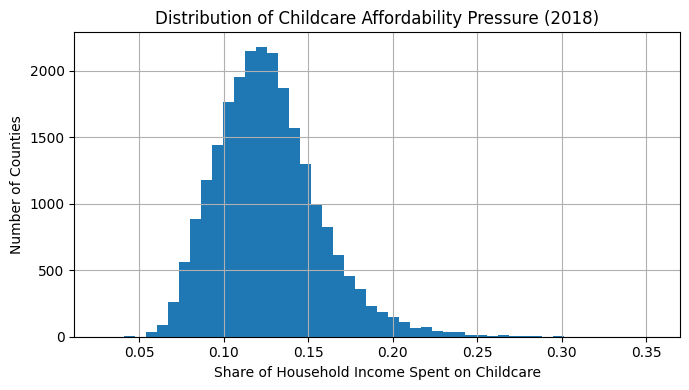

In [20]:
plt.figure(figsize=(7,4))
df["afford_ratio_annual"].dropna().hist(bins=50)
plt.title("Distribution of Childcare Affordability Pressure (2018)")
plt.xlabel("Share of Household Income Spent on Childcare")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()


Most counties cluster around spending 10–15% of household income on childcare, with a long right tail where costs exceed 30% in the most expensive areas.

### 4.1.2 EDA of Childcare Costs, Affordability, and Maternal Labor Force Participation

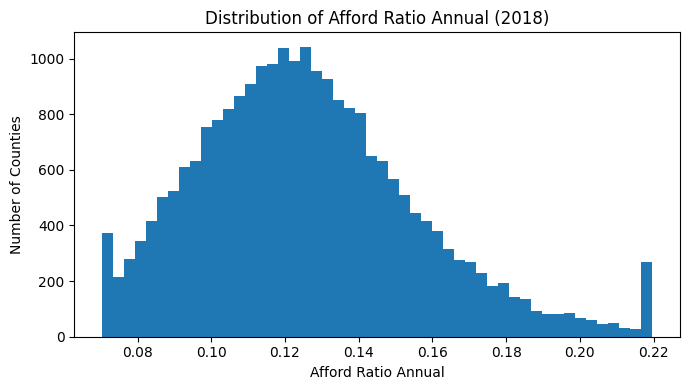

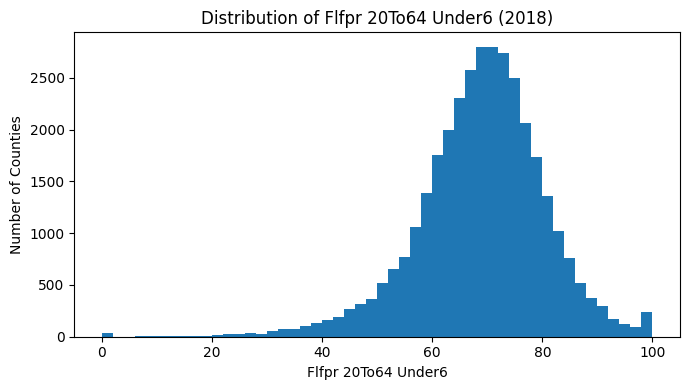

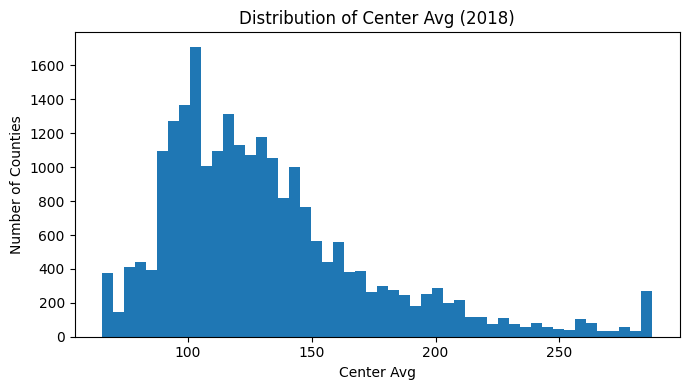

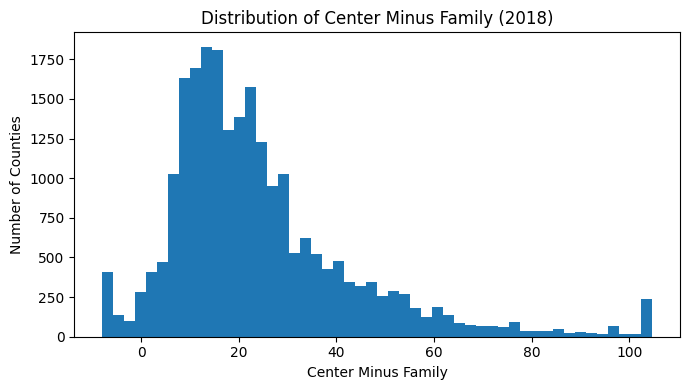

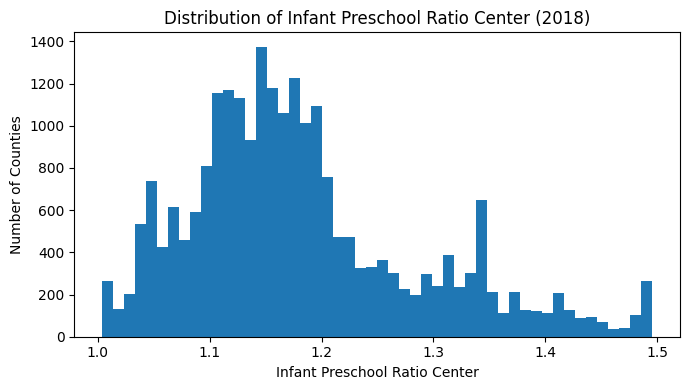

In [24]:
aff_col = "afford_ratio_annual" if "afford_ratio_annual" in df.columns else "afford_ratio"
eda_cols_keep = [
    aff_col,
    maternal_lfp_col,
    "center_avg",
    "center_minus_family",
    "infant_preschool_ratio_center"
]

eda_cols_keep = [c for c in eda_cols_keep if c in df.columns]

for col in eda_cols_keep:
    plt.figure(figsize=(7,4))

    x = df[col].dropna()


    if col != maternal_lfp_col:
        x = x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))

    plt.hist(x, bins=50)
    plt.title(f"Distribution of {col.replace('_',' ').title()} (2018)")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Number of Counties")
    plt.tight_layout()
    plt.show()


### 4.1.3 Price Difference Between Center- and Family-Based Childcare

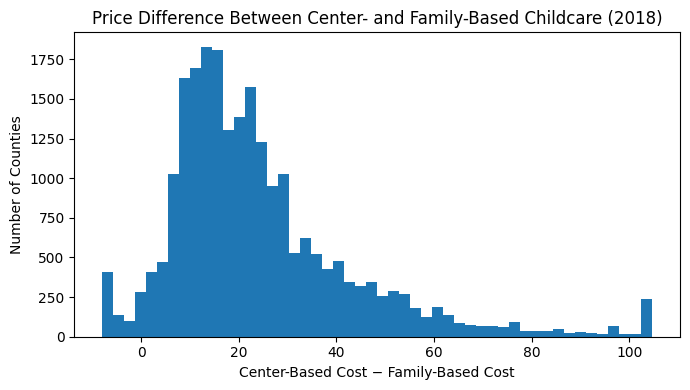

In [26]:
plt.figure(figsize=(7,4))
x = df["center_minus_family"].dropna()

# Light clipping to avoid extreme outliers dominating the histogram
x = x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))

plt.hist(x, bins=50)
plt.title("Price Difference Between Center- and Family-Based Childcare (2018)")
plt.xlabel("Center-Based Cost − Family-Based Cost")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

Most counties exhibit a positive price gap, indicating that center-based childcare is generally more expensive than family-based care, while a long right tail highlights counties with especially large cost premiums.

In [30]:
import matplotlib.pyplot as plt
def clipped_series(s, low=0.01, high=0.99):
    s = s.dropna()
    if len(s) == 0:
        return s
    return s.clip(lower=s.quantile(low), upper=s.quantile(high))

# Choose the right affordability column
burden_col = "afford_ratio_annual" if "afford_ratio_annual" in df.columns else "afford_ratio"

### 4.1.4 Distribution of Childcare Burden (share of income) + median line

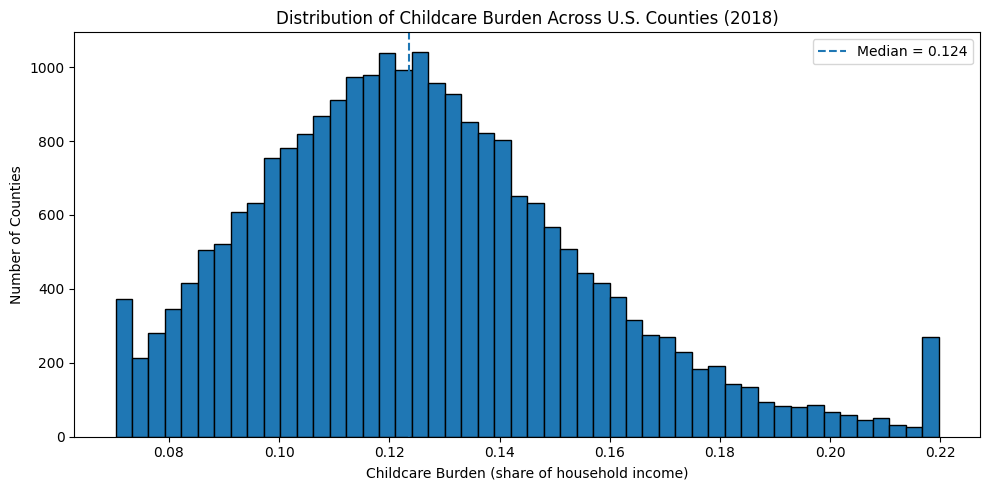

In [31]:
x = clipped_series(df[burden_col])

plt.figure(figsize=(10,5))
plt.hist(x, bins=50, edgecolor="black")
plt.axvline(x.median(), linestyle="--", label=f"Median = {x.median():.3f}")
plt.title("Distribution of Childcare Burden Across U.S. Counties (2018)")
plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Number of Counties")
plt.legend()
plt.tight_layout()
plt.show()

Most counties spend around 12% of household income on childcare, but the distribution has a clear right tail, showing that families in some counties face much heavier cost pressure, with childcare taking up over 20% of income.

### 4.1.4 Childcare Burden vs Maternal Labor Force Participation

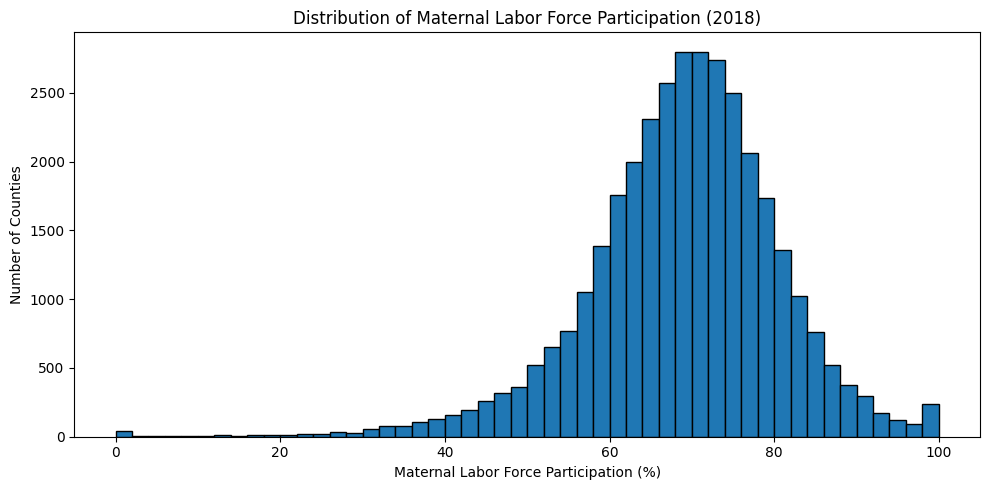

In [32]:
x = clipped_series(df[maternal_lfp_col], low=0.00, high=1.00)  # no clipping needed usually, but safe

plt.figure(figsize=(10,5))
plt.hist(x, bins=50, edgecolor="black")
plt.title("Distribution of Maternal Labor Force Participation (2018)")
plt.xlabel("Maternal Labor Force Participation (%)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

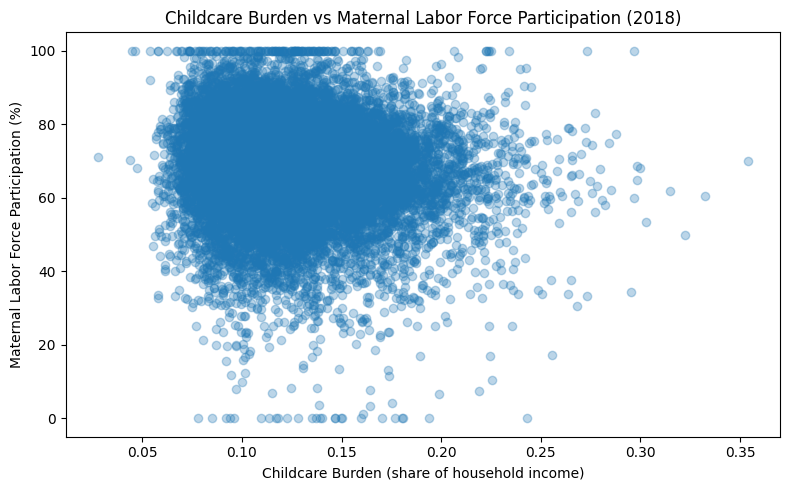

In [37]:
x = df["afford_ratio_annual"]
y = df[maternal_lfp_col]

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Maternal Labor Force Participation (%)")
plt.title("Childcare Burden vs Maternal Labor Force Participation (2018)")
plt.tight_layout()
plt.show()

The scatter shows a weak but noticeable downward pattern, where counties with higher childcare burden tend to have slightly lower maternal labor force participation. While there is substantial overlap and noise, the overall pattern suggests that higher childcare costs may act as a constraint on mothers’ ability to work.

## 4.2Clustering

In [56]:
cluster_features = [
    "afford_ratio_annual",
    "infant_preschool_ratio_center",
    "infant_preschool_ratio_family",
    "center_minus_family",
    "center_over_family"
]

X_raw = df[cluster_features].copy()

# Preprocessing: impute + scale
prep = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = prep.fit_transform(X_raw)

print("X shape:", X.shape)

X shape: (34567, 5)


# 5.K means Analysis

### 5.1 Elbow Method

In [57]:
inertias = []

k_values = [2, 3, 4, 5, 6, 7, 8]

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

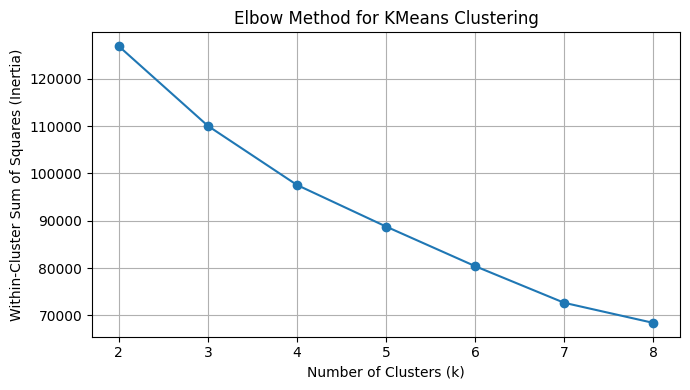

In [12]:
# Plot Elbow curve
plt.figure(figsize=(7,4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for KMeans Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.2 silhouette Method

In [9]:
results = []
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    results.append((k, sil))

results_df = pd.DataFrame(results, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
results_df

,k,silhouette
0,3,0.457675
3,6,0.331946
2,5,0.319666
1,4,0.305532


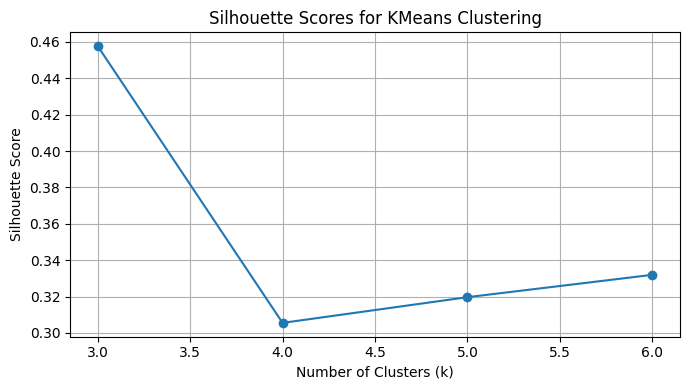

In [10]:
results_df_sorted = results_df.sort_values("k")

plt.figure(figsize=(7,4))
plt.plot(results_df_sorted["k"], results_df_sorted["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans Clustering")
plt.grid(True)
plt.tight_layout()
plt.show()


Silhouette analysis indicates that k = 3 provides the strongest cluster separation among the values tested, with a substantially higher silhouette score than larger k. In contrast, the elbow method shows a smooth decline in within-cluster variance without a clearly defined inflection point, suggesting no uniquely optimal number of clusters based on inertia alone. Given the exploratory nature of this milestone, k = 3 was selected as it balances quantitative cluster quality with interpretability, while avoiding over-segmentation of counties into weakly separated groups

### 5.3 clustering

In [39]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X)


In [40]:
cluster_summary = (
    df.groupby("kmeans_cluster")[cluster_features]
    .mean()
    .round(3)
)

cluster_summary

,afford_ratio_annual,infant_preschool_ratio_center,infant_preschool_ratio_family,center_minus_family,center_over_family
kmeans_cluster,,,,,
0,0.120,1.147,1.066,16.890,1.172
1,0.155,1.270,1.088,58.469,1.428
2,0.125,1.284,1.231,21.520,1.208


In [41]:
df["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,27810
1,3959
2,2798


In [45]:
cluster_labels = {
    0: "Low Burden / Balanced Costs",
    1: "Moderate Burden / Center Premium",
    2: "High Burden / High Cost Pressure"
}

df["cluster_label"] = df["kmeans_cluster"].map(cluster_labels)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


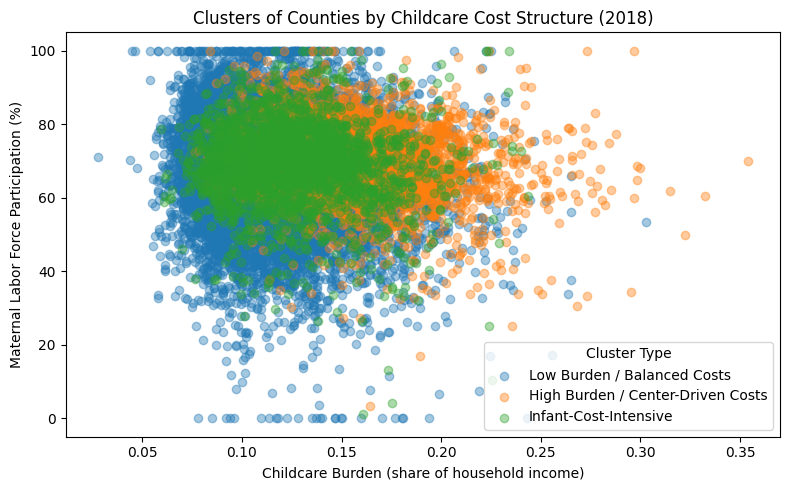

In [48]:
import matplotlib.pyplot as plt

# Define readable labels and colors
cluster_labels = {
    0: "Low Burden / Balanced Costs",
    1: "High Burden / Center-Driven Costs",
    2: "Infant-Cost-Intensive"
}

colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}

plt.figure(figsize=(8,5))

for c in sorted(df["kmeans_cluster"].unique()):
    subset = df[df["kmeans_cluster"] == c]
    plt.scatter(
        subset["afford_ratio_annual"],
        subset[maternal_lfp_col],
        alpha=0.4,
        color=colors[c],
        label=cluster_labels[c]
    )

plt.xlabel("Childcare Burden (share of household income)")
plt.ylabel("Maternal Labor Force Participation (%)")
plt.title("Clusters of Counties by Childcare Cost Structure (2018)")
plt.legend(title="Cluster Type")
plt.tight_layout()
plt.show()


The clustering identifies three childcare cost environments: low-burden balanced markets (blue), high-burden center-driven markets (orange), and infant-cost-intensive markets (green). Clusters differ strongly along childcare burden (x-axis), while maternal labor force participation shows substantial overlap across clusters, suggesting other local factors also influence labor outcomes.

# 6.Hierarchical Clustering Analysis

In [15]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

hier_results = []
k_values = [2, 3, 4, 5, 6, 7, 8]

for k in k_values:
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")  # ward works well with scaled numeric data
    labels = hc.fit_predict(X)
    sil = silhouette_score(X, labels)
    hier_results.append((k, sil))

hier_results_df = pd.DataFrame(hier_results, columns=["k", "silhouette"]).sort_values("k")
hier_results_df


,k,silhouette
0,2,0.419835
1,3,0.401039
2,4,0.242261
3,5,0.250517
4,6,0.256710
5,7,0.271678
6,8,0.279849


### 6.2 silhouette Method

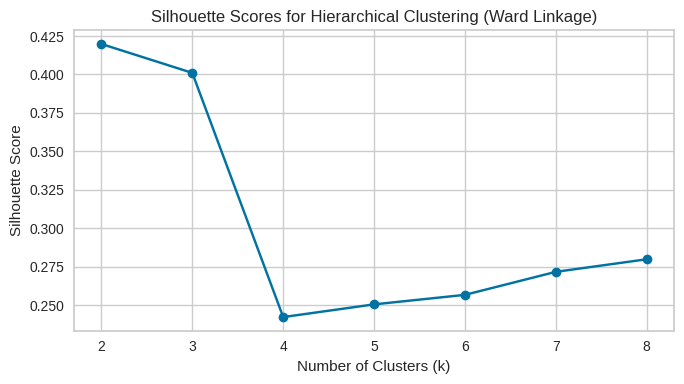

In [16]:
plt.figure(figsize=(7,4))
plt.plot(hier_results_df["k"], hier_results_df["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering (Ward Linkage)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
best_k_hier = hier_results_df.loc[hier_results_df["silhouette"].idxmax(), "k"]
best_sil_hier = hier_results_df["silhouette"].max()

print("Best k (Hierarchical) =", int(best_k_hier))
print("Best silhouette (Hierarchical) =", round(float(best_sil_hier), 4))


Best k (Hierarchical) = 2
Best silhouette (Hierarchical) = 0.4198


In [18]:
hc_final = AgglomerativeClustering(n_clusters=int(best_k_hier), linkage="ward")
df["cluster_hier"] = hc_final.fit_predict(X)

df["cluster_hier"].value_counts().sort_index()


,count
cluster_hier,
0,7894
1,26673


## 6.3 Dendrogram

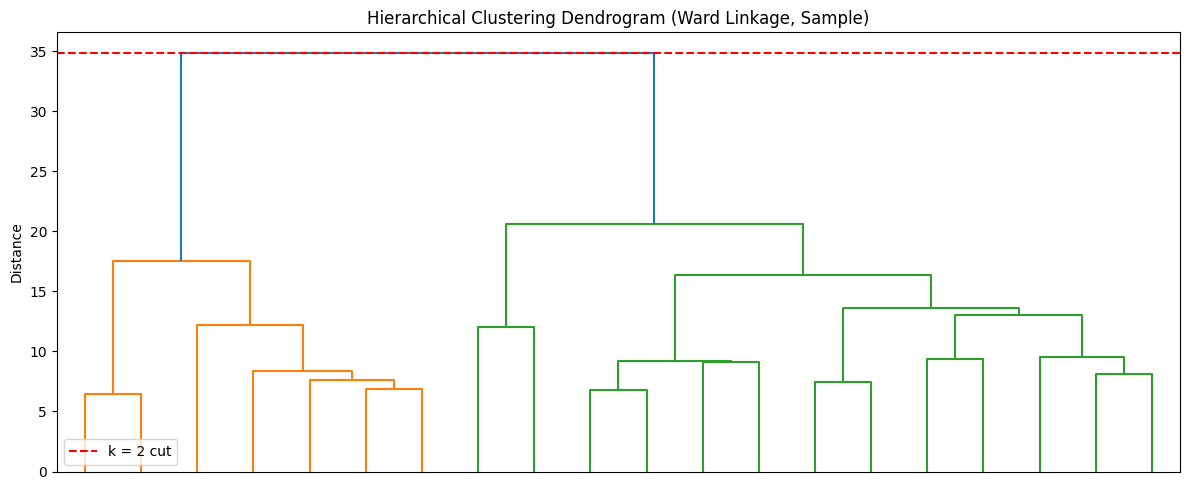

In [49]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Sample for visualization only
sample_n = 400
sample_df = df.sample(n=sample_n, random_state=42)

# Use same features + preprocessing
X_sample = prep.transform(sample_df[cluster_features])

# Ward linkage
Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12,5))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,                 # fewer, clearer merges
    show_leaf_counts=True,
    no_labels=True
)
plt.axhline(y=Z[-(2-1), 2], color="red", linestyle="--", label="k = 2 cut")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage, Sample)")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

# 7.Conclusion

This analysis shows that U.S. counties cluster into distinct childcare market types based on affordability pressure and pricing structure. Using hierarchical and K-Means clustering, we identify a dominant split between lower- and higher-burden counties, as well as three more nuanced market types characterized by balanced costs, center-driven cost pressure, and infant-cost-intensive pricing. While higher childcare burden is associated with greater cost pressure, maternal labor force participation varies substantially within each cluster. Notably, some high-cost counties maintain relatively high maternal participation, while some lower-cost counties continue to exhibit low participation. These patterns suggest that childcare affordability is an important but incomplete determinant of maternal labor supply, with other local labor market and institutional factors likely playing a complementary role.